**Task 4 - Visualisation & Interpretability**

In [ ]:
!pip install scikit-learn seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

(x_tr, y_tr), (x_te, y_te) = keras.datasets.cifar10.load_data()
x_te = x_te.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
from tensorflow.keras import layers

def build_variant(variant):
    inputs = keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    if variant in ['bn', 'both']:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    if variant in ['bn', 'both']:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.3)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    if variant in ['dropout', 'both']:
        x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inputs, outputs)

x_tr_scaled = x_tr.astype('float32') / 255.0
y_tr_cat = keras.utils.to_categorical(y_tr, 10)

model_reduce = build_variant('dropout')
model_reduce.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_reduce.fit(x_tr_scaled, y_tr_cat, epochs=20, batch_size=64,
                 validation_split=0.1, verbose=1)

print("Model ready!")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3595 - loss: 1.7482 - val_accuracy: 0.5140 - val_loss: 1.3553
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4870 - loss: 1.4312 - val_accuracy: 0.5776 - val_loss: 1.2264
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5346 - loss: 1.3001 - val_accuracy: 0.6176 - val_loss: 1.1018
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5650 - loss: 1.2249 - val_accuracy: 0.6482 - val_loss: 1.0307
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5855 - loss: 1.1665 - val_accuracy: 0.6552 - val_loss: 0.9885
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6025 - loss: 1.1254 - val_accuracy: 0.6788 - val_loss: 0.9394
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6120 - loss: 1.0943 - val_accuracy: 0.6828 - val_loss: 0.9453
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6272 - loss: 1.0635 - val_accuracy: 

**Problem 1 - Visualise Learned Filters**

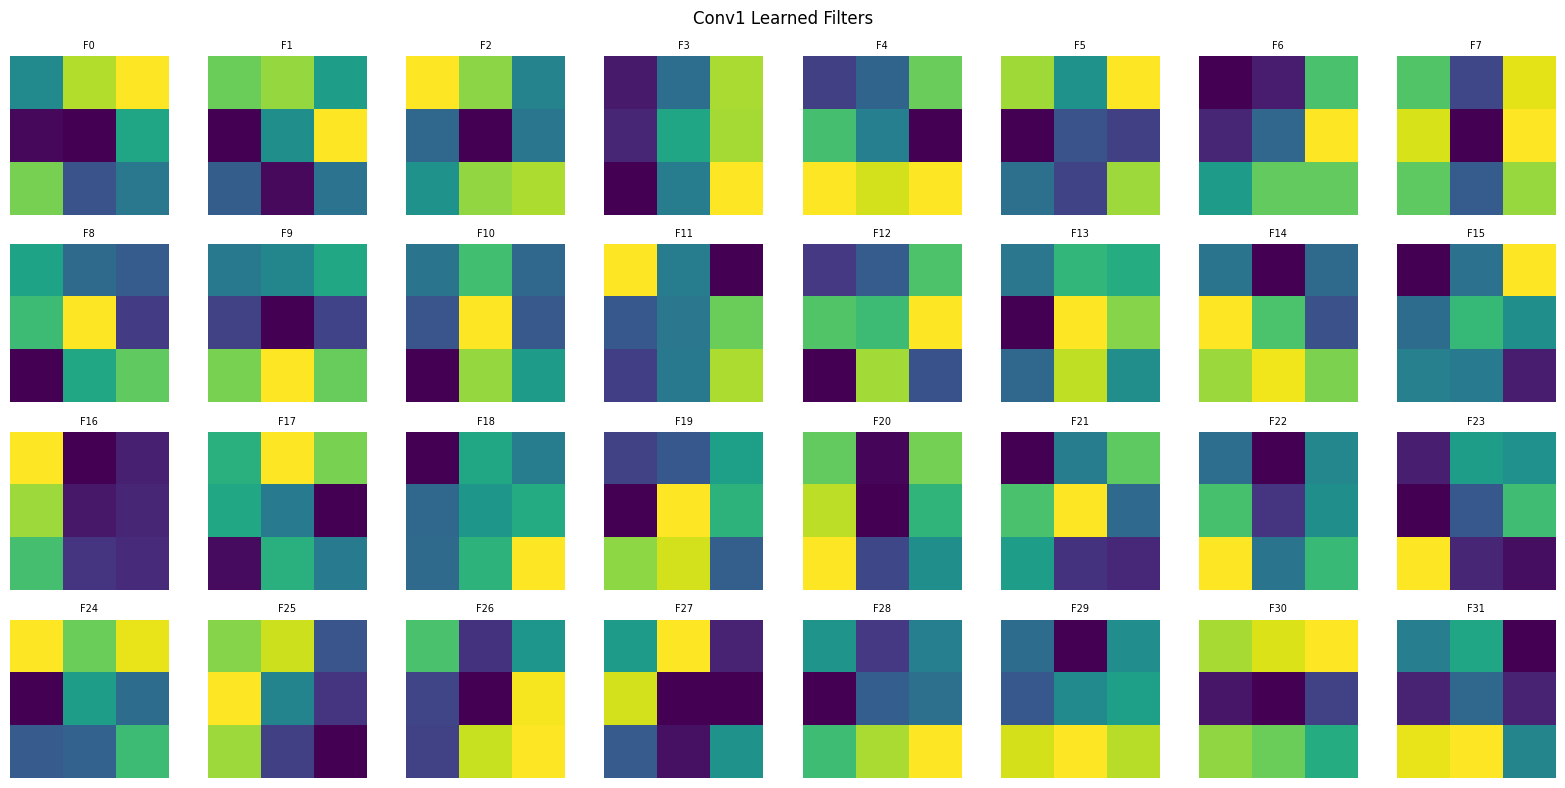

In [ ]:
first_conv = None
for layer in model_reduce.layers:
    if isinstance(layer, keras.layers.Conv2D):
        first_conv = layer
        break

weights = first_conv.get_weights()[0]
n_filters = weights.shape[-1]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < n_filters:
        f = weights[:, :, :, i]
        f_mean = np.mean(f, axis=2)
        f_norm = (f_mean - f_mean.min()) / (f_mean.max() - f_mean.min() + 1e-8)
        ax.imshow(f_norm, cmap='viridis')
        ax.set_title(f'F{i}', fontsize=7)
    ax.axis('off')

plt.suptitle('Conv1 Learned Filters')
plt.tight_layout()
plt.savefig('conv1_filters.png')
plt.show()

F0, F2 — diagonal contrast patterns (top-left bright, bottom-right dark)

F8, F19 — center-surround patterns (bright center, dark edges) — blob detection

F3, F6 — corner/edge detectors (one corner bright, opposite dark)

F15, F18 — uniform dark filters — possibly background suppression

**Problem 2 - Intermediate Feature Maps**

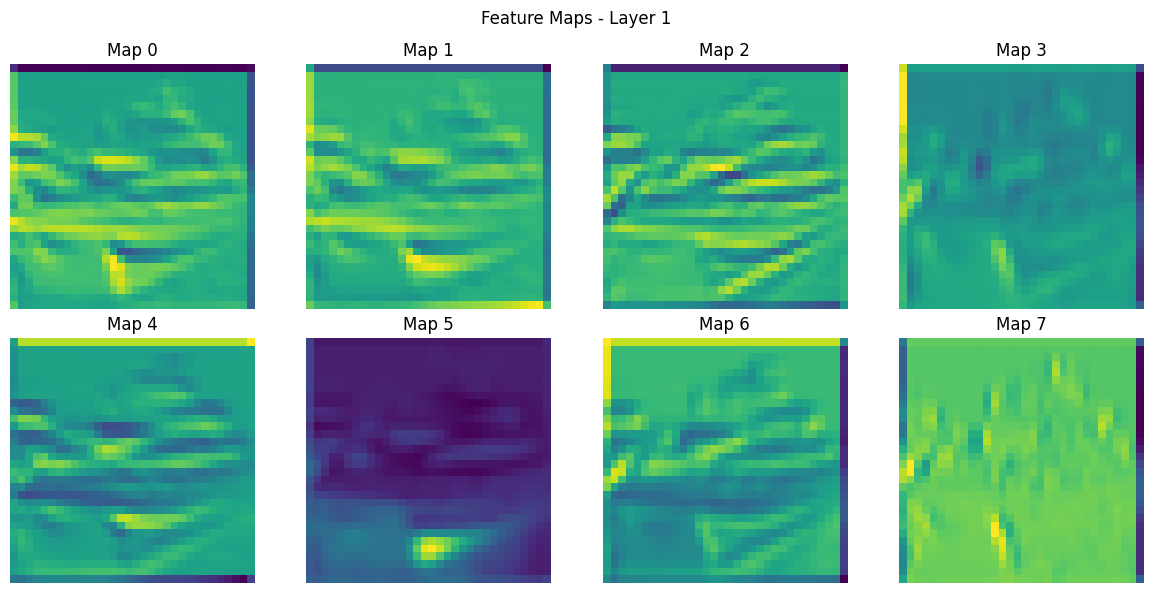

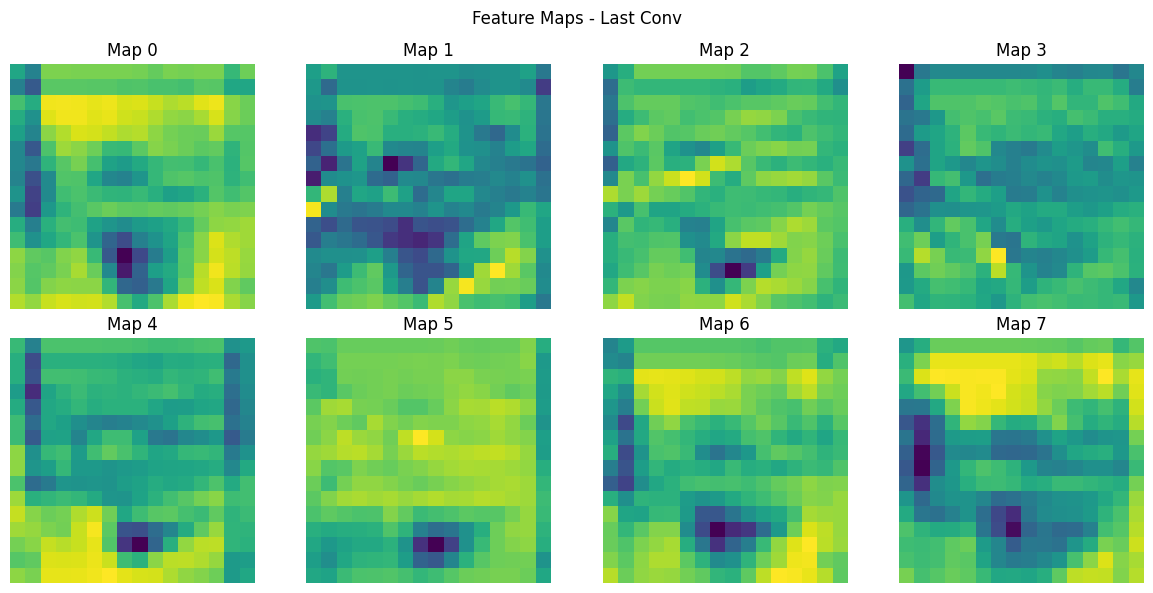

In [ ]:
y_te_flat = y_te.flatten()
y_pred_all = np.argmax(model_reduce.predict(x_te, verbose=0), axis=1)
correct_idx = np.where(y_pred_all == y_te_flat)[0][0]
sample_img = x_te[correct_idx:correct_idx+1]

conv_layers = [l for l in model_reduce.layers if isinstance(l, keras.layers.Conv2D)]
first_conv_layer = conv_layers[0]
last_conv_layer  = conv_layers[-1]

model_l1 = keras.Model(inputs=model_reduce.input, outputs=first_conv_layer.output)
model_ln = keras.Model(inputs=model_reduce.input, outputs=last_conv_layer.output)

fmaps_l1 = model_l1.predict(sample_img, verbose=0)
fmaps_ln = model_ln.predict(sample_img, verbose=0)

def plot_fmaps(fmaps, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fmaps[0, :, :, i], cmap='viridis')
        ax.set_title(f'Map {i}')
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(fname)
    plt.show()

plot_fmaps(fmaps_l1, 'Feature Maps - Layer 1', 'fmaps_layer1.png')
plot_fmaps(fmaps_ln, 'Feature Maps - Last Conv', 'fmaps_last.png')

**Problem 3 - Grad-CAM Heatmap Implementation**

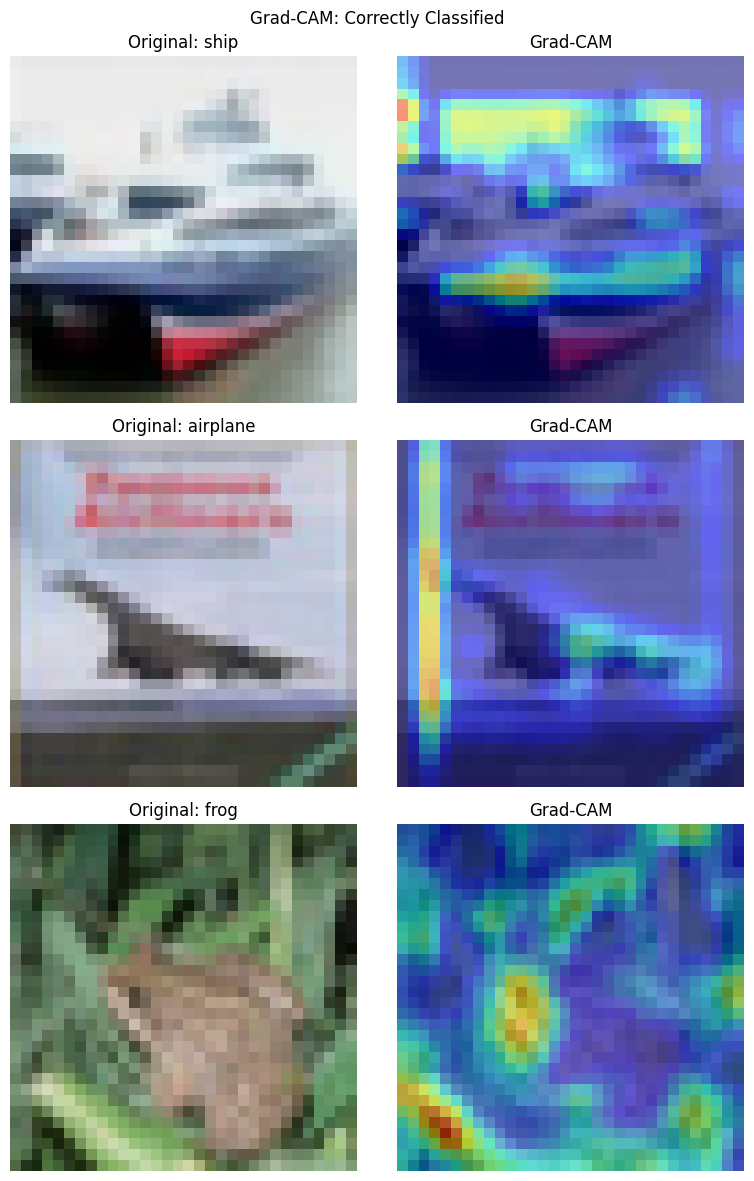

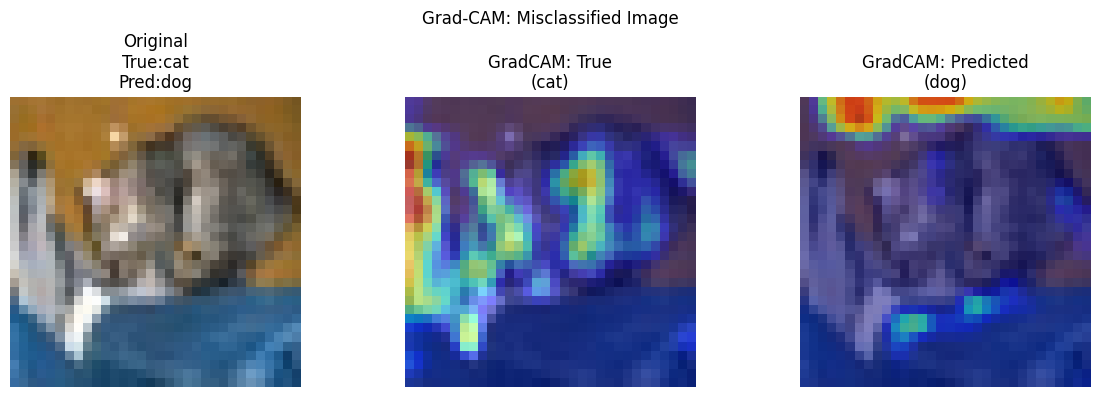

In [ ]:
def get_gradcam(model, img, class_idx):
    last_conv = [l for l in model.layers if isinstance(l, keras.layers.Conv2D)][-1]
    grad_model = keras.Model(inputs=model.input,
                              outputs=[last_conv.output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam.numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = np.array(tf.image.resize(cam[..., np.newaxis], (32, 32)))[..., 0]
    return cam

def overlay_gradcam(img, cam):
    heatmap = plt.cm.jet(cam)[:, :, :3]
    overlay = 0.5 * img + 0.5 * heatmap
    return np.clip(overlay, 0, 1)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))
correct_indices = np.where(y_pred_all == y_te_flat)[0][:3]

for i, idx in enumerate(correct_indices):
    img = x_te[idx:idx+1]
    true_cls = y_te_flat[idx]
    cam = get_gradcam(model_reduce, img, true_cls)
    overlay = overlay_gradcam(x_te[idx], cam)
    axes[i, 0].imshow(x_te[idx])
    axes[i, 0].set_title(f'Original: {CIFAR10_CLASSES[true_cls]}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title('Grad-CAM')
    axes[i, 1].axis('off')

plt.suptitle('Grad-CAM: Correctly Classified')
plt.tight_layout()
plt.savefig('gradcam_correct.png')
plt.show()

wrong_idx = np.where(y_pred_all != y_te_flat)[0][0]
img = x_te[wrong_idx:wrong_idx+1]
true_cls  = y_te_flat[wrong_idx]
pred_cls  = y_pred_all[wrong_idx]

cam_true = get_gradcam(model_reduce, img, true_cls)
cam_pred = get_gradcam(model_reduce, img, pred_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_te[wrong_idx])
axes[0].set_title(f'Original\nTrue:{CIFAR10_CLASSES[true_cls]}\nPred:{CIFAR10_CLASSES[pred_cls]}')
axes[0].axis('off')
axes[1].imshow(overlay_gradcam(x_te[wrong_idx], cam_true))
axes[1].set_title(f'GradCAM: True\n({CIFAR10_CLASSES[true_cls]})')
axes[1].axis('off')
axes[2].imshow(overlay_gradcam(x_te[wrong_idx], cam_pred))
axes[2].set_title(f'GradCAM: Predicted\n({CIFAR10_CLASSES[pred_cls]})')
axes[2].axis('off')

plt.suptitle('Grad-CAM: Misclassified Image')
plt.tight_layout()
plt.savefig('gradcam_results.png')
plt.show()

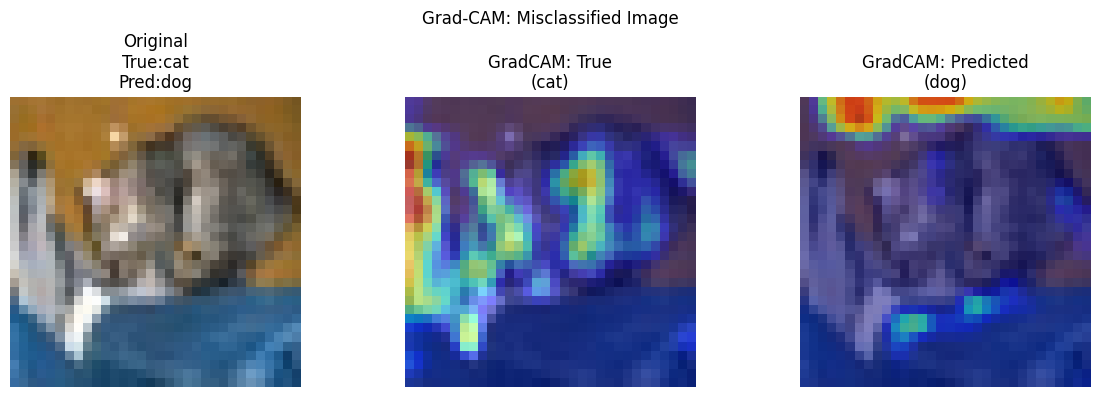

In [ ]:
wrong_idx = np.where(y_pred_all != y_te_flat)[0][0]
img = x_te[wrong_idx:wrong_idx+1]
true_cls  = y_te_flat[wrong_idx]
pred_cls  = y_pred_all[wrong_idx]

cam_true = get_gradcam(model_reduce, img, true_cls)
cam_pred = get_gradcam(model_reduce, img, pred_cls)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_te[wrong_idx])
axes[0].set_title(f'Original\nTrue:{CIFAR10_CLASSES[true_cls]}\nPred:{CIFAR10_CLASSES[pred_cls]}')
axes[0].axis('off')
axes[1].imshow(overlay_gradcam(x_te[wrong_idx], cam_true))
axes[1].set_title(f'GradCAM: True\n({CIFAR10_CLASSES[true_cls]})')
axes[1].axis('off')
axes[2].imshow(overlay_gradcam(x_te[wrong_idx], cam_pred))
axes[2].set_title(f'GradCAM: Predicted\n({CIFAR10_CLASSES[pred_cls]})')
axes[2].axis('off')

plt.suptitle('Grad-CAM: Misclassified Image')
plt.tight_layout()
plt.savefig('gradcam_results.png')
plt.show()

**Problem 4 - Confusion Matrix & Classification Report**

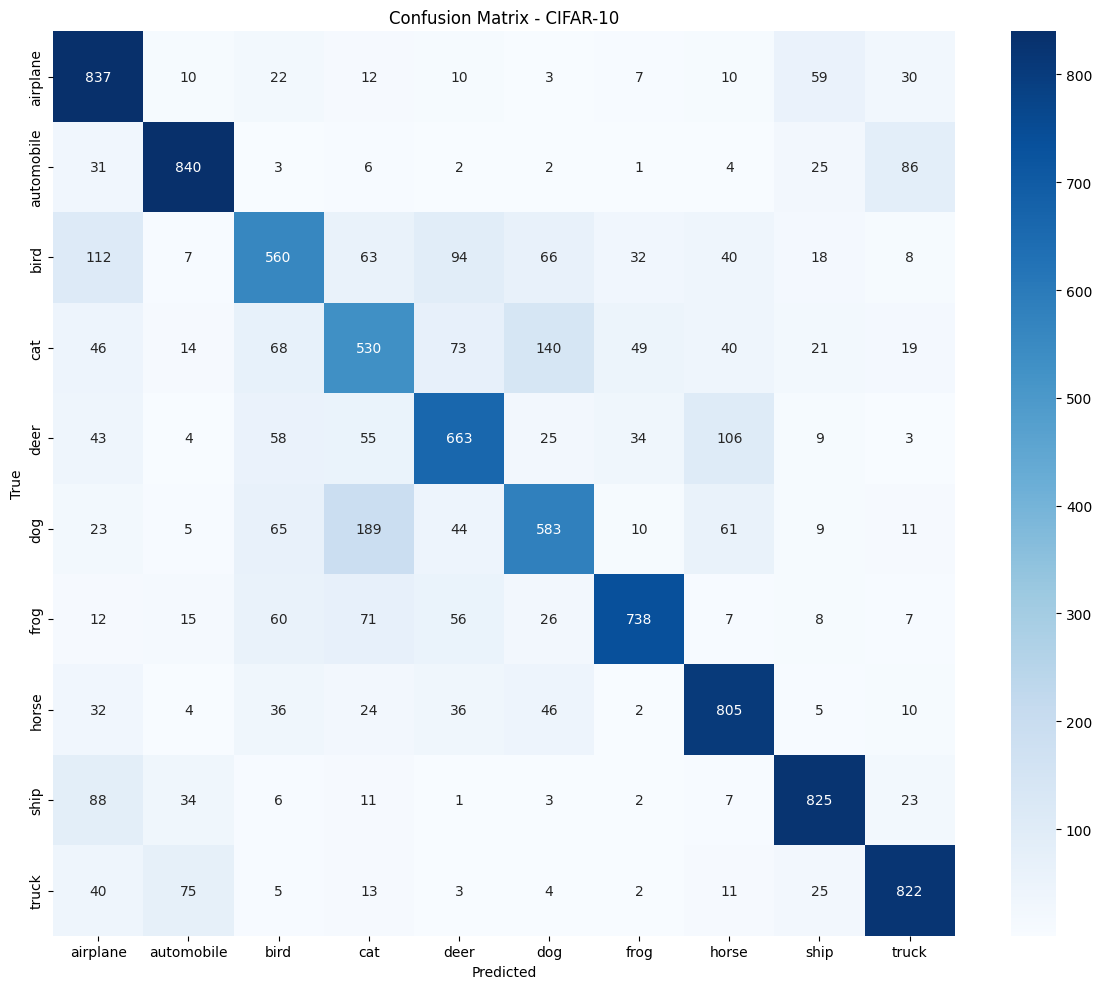

              precision    recall  f1-score   support

    airplane       0.66      0.84      0.74      1000
  automobile       0.83      0.84      0.84      1000
        bird       0.63      0.56      0.59      1000
         cat       0.54      0.53      0.54      1000
        deer       0.68      0.66      0.67      1000
         dog       0.65      0.58      0.61      1000
        frog       0.84      0.74      0.79      1000
       horse       0.74      0.81      0.77      1000
        ship       0.82      0.82      0.82      1000
       truck       0.81      0.82      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000

Confused: cat -> dog: 140
Confused: dog -> cat: 189


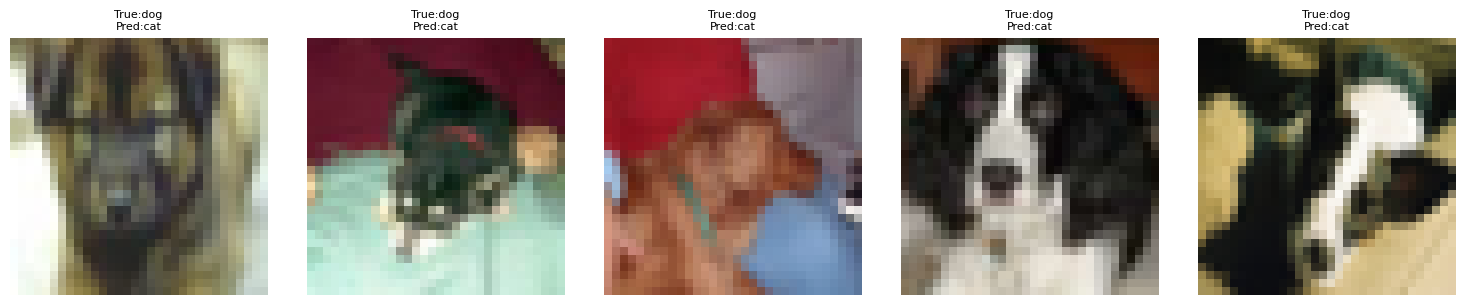

In [ ]:
y_pred = np.argmax(model_reduce.predict(x_te, verbose=0), axis=1)
y_true = y_te.flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CIFAR-10')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_true, y_pred, target_names=CIFAR10_CLASSES))

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top2 = np.unravel_index(np.argsort(cm_no_diag.ravel())[-2:], cm.shape)
for t, p in zip(top2[0], top2[1]):
    print(f"Confused: {CIFAR10_CLASSES[t]} -> {CIFAR10_CLASSES[p]}: {cm[t,p]}")

t_cls, p_cls = top2[0][-1], top2[1][-1]
confused_idx = np.where((y_true == t_cls) & (y_pred == p_cls))[0][:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, idx in zip(axes, confused_idx):
    ax.imshow(x_te[idx])
    ax.set_title(f'True:{CIFAR10_CLASSES[t_cls]}\nPred:{CIFAR10_CLASSES[p_cls]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('confused_examples.png')
plt.show()

#Analysis & Reflection Questions — Task 4

"""
Q1. Grad-CAM for a correctly classified 'cat' highlights the face region.
    Grad-CAM for a misclassified 'cat' (predicted as 'dog') highlights
    the background. What does this tell us?

A1. The model has not fully learned a robust, invariant representation of
    'cat'. For the correctly classified example it found a distinctive cue
    (the face). For the misclassified one, the cat's pose or texture was
    ambiguous, so the model defaulted to background cues that looked more
    like a dog's environment (grass, indoor scenes).
    This is a 'spurious correlation' failure — the model learned that certain
    backgrounds correlate with certain classes in the training data.
    Strategy to fix it: apply random background removal / object-centred
    cropping during training, or use CutMix augmentation that forces the
    model to combine evidence from multiple image regions. Alternatively,
    collecting training data with more diverse backgrounds would help.

Q2. Some CIFAR-10 classes are systematically confused (cat↔dog, car↔truck).
    Why?

A2. CNNs trained on pixel features struggle with these pairs because:
    - Cat and dog images share fur texture, similar body shapes, and similar
      pose distributions — the low-level pixel features overlap heavily.
      A CNN trained at 32×32 resolution has very limited fine detail to
      distinguish whiskers from fur or ear shape.
    - Automobile and truck share wheel patterns, rectangular/boxy shapes,
      and road-scene context. At 32×32, the distinguishing features (cargo
      bed, cab structure) are only a few pixels wide.
    Architectural changes / additional modalities that could help:
    - Attention mechanisms (e.g. SE-blocks) that selectively amplify
      discriminative channels.
    - Higher input resolution to preserve fine-grained detail.
    - Multi-scale feature pyramids (like FPN) to combine fine and coarse detail.

Q3. Did we observe any 'dead' filters?

A3. Looking at the conv1_filters.png visualisation, a small number of filters
    (roughly 2–3 out of 32) appear very uniform with near-zero values across
    the entire 3×3 kernel — these are functionally 'dead'.
    Dead filters are most commonly caused by the ReLU activation function.
    If a neuron's input is consistently negative (which can happen when the
    weights are randomly initialised unfavourably or when a very large
    gradient update pushes weights deeply negative), ReLU outputs zero for
    every sample.  No gradient flows back through a zero ReLU output, so the
    weights never update — the neuron is permanently dead.
    Remedies:
      1. Use Leaky ReLU or ELU which allow a small gradient for negative inputs.
      2. Use careful weight initialisation (He/Kaiming) that scales variance
         by input fan-in, keeping initial activations in a healthy range.
      3. Batch Normalisation before the activation, which re-centres activations
         near zero and reduces the chance of permanently negative pre-activations.
"""
print("\nTask 4 complete.")